In [44]:
import pandas as pd
import numpy as no
from mlxtend.plotting import plot_decision_regions

In [45]:
df = pd.DataFrame()

In [46]:
df['X1'] = [0,1,2,3,4,5,6,7,8,9]
df['X2'] = [9,1,6,7,2,3,3,8,1,0]
df['label'] = [1,1,0,1,0,1,0,1,0,1]

In [47]:
df.head()

,X1,X2,label
0,0,9,1
1,1,1,1
2,2,6,0
3,3,7,1
4,4,2,0


<Axes: xlabel='X1', ylabel='X2'>

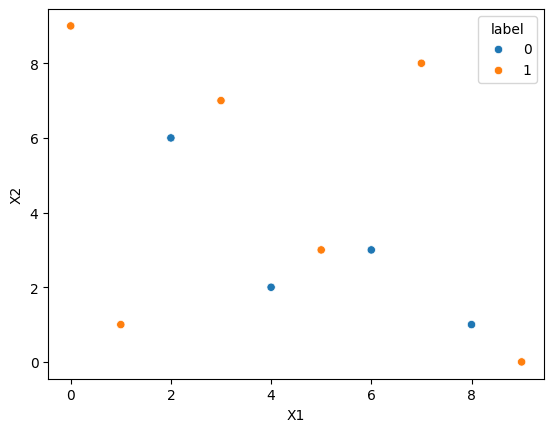

In [48]:
import seaborn as sns
sns.scatterplot(data=df, x='X1', y='X2', hue='label')

In [49]:
df['weights'] = 1/len(df)
df.head(10)

,X1,X2,label,weights
0,0,9,1,0.1
1,1,1,1,0.1
2,2,6,0,0.1
3,3,7,1,0.1
4,4,2,0,0.1
5,5,3,1,0.1
6,6,3,0,0.1
7,7,8,1,0.1
8,8,1,0,0.1
9,9,0,1,0.1


In [50]:
from sklearn.tree import DecisionTreeClassifier
dt1 = DecisionTreeClassifier(max_depth=1)

In [51]:
X = df[['X1','X2']].values
y = df['label'].values

In [52]:
dt1.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

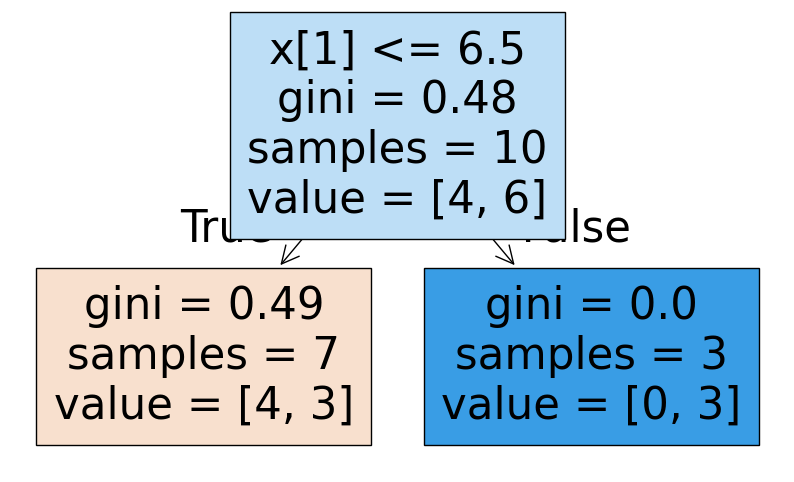

In [53]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plot_tree(dt1, filled=True)
plt.show()

<Axes: >

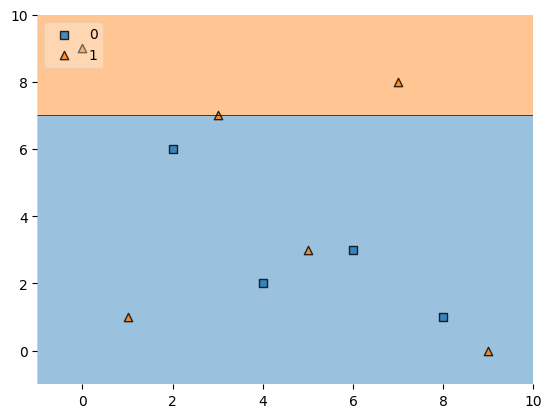

In [54]:
from matplotlib.pyplot import plot


plot_decision_regions(X, y, clf=dt1, legend=2)

In [55]:
df['y_pred'] = dt1.predict(X)
df.head(10)

,X1,X2,label,weights,y_pred
0,0,9,1,0.1,1
1,1,1,1,0.1,0
2,2,6,0,0.1,0
3,3,7,1,0.1,1
4,4,2,0,0.1,0
5,5,3,1,0.1,0
6,6,3,0,0.1,0
7,7,8,1,0.1,1
8,8,1,0,0.1,0
9,9,0,1,0.1,0


In [56]:
import numpy as np
def calculate_model_weight(error):
    return 0.5 * np.log((1-error)/error)

In [57]:
alpha = calculate_model_weight(0.3)
print(alpha)

0.42364893019360184


In [58]:
# step 4
def update_row_weights(row, alpha):
    if row['label'] == row['y_pred']:
        return row['weights'] * np.exp(-alpha)
    else:
        return row['weights'] * np.exp(alpha)

In [59]:
df['updated_weights'] = df.apply(lambda row: update_row_weights(row, alpha), axis=1)

In [60]:
df.head()

,X1,X2,label,weights,y_pred,updated_weights
0,0,9,1,0.1,1,0.065465
1,1,1,1,0.1,0,0.152753
2,2,6,0,0.1,0,0.065465
3,3,7,1,0.1,1,0.065465
4,4,2,0,0.1,0,0.065465


In [61]:
df['normalized_weights'] = df['updated_weights'] / df['updated_weights'].sum()
df.head()

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
0,0,9,1,0.1,1,0.065465,0.071429
1,1,1,1,0.1,0,0.152753,0.166667
2,2,6,0,0.1,0,0.065465,0.071429
3,3,7,1,0.1,1,0.065465,0.071429
4,4,2,0,0.1,0,0.065465,0.071429


In [ ]:
df['cumsum_upper'] = df['normalized_weights'].cumsum()
df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weights'] 
df.head()

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,cumsum_upper,cumsum_lower
0,0,9,1,0.1,1,0.065465,0.071429,0.071429,0.000000
1,1,1,1,0.1,0,0.152753,0.166667,0.238095,0.071429
2,2,6,0,0.1,0,0.065465,0.071429,0.309524,0.238095
3,3,7,1,0.1,1,0.065465,0.071429,0.380952,0.309524
4,4,2,0,0.1,0,0.065465,0.071429,0.452381,0.380952


Random values used for weighted sampling:
[0.24539951 0.72225084 0.12130615 0.60120364 0.06212579 0.12745915
 0.27045966 0.51694562 0.09632945 0.511927  ]

Resampled dataset for the next weak learner:


,X1,X2,label
0,2,6,0
1,7,8,1
2,1,1,1
3,5,3,1
4,0,9,1
5,1,1,1
6,2,6,0
7,5,3,1
8,1,1,1
9,5,3,1


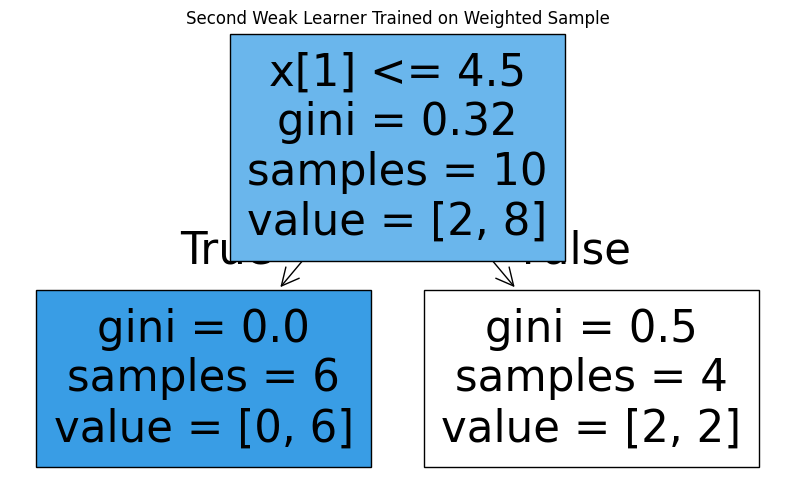

In [63]:
# step 5: sample the next training set using the normalized weights
random_values = np.random.rand(len(df))

def find_row_index(r):
    for idx, row in df.iterrows():
        if row['cumsum_lower'] < r <= row['cumsum_upper']:
            return idx
    return df.index[-1]

sampled_indices = [find_row_index(r) for r in random_values]
resampled_df = df.loc[sampled_indices, ['X1', 'X2', 'label']].reset_index(drop=True)

print('Random values used for weighted sampling:')
print(random_values)
print('\nResampled dataset for the next weak learner:')
display(resampled_df)

# Train a second decision stump on the resampled data
X_resampled = resampled_df[['X1', 'X2']].values
y_resampled = resampled_df['label'].values

second_tree = DecisionTreeClassifier(max_depth=1, random_state=42)
second_tree.fit(X_resampled, y_resampled)

plt.figure(figsize=(10, 6))
plot_tree(second_tree, filled=True)
plt.title('Second Weak Learner Trained on Weighted Sample')
plt.show()